# 2D-1D deconvolution of NGC 3110 and NGC 2369, per configuration

Project **2017.1.00255.S**, CO(2-1). For each galaxy, the extended and the
compact 12m configurations are deconvolved **separately** (never combined),
then restored with a Gaussian clean beam:

| configuration | restored with |
|---|---|
| extended | its own clean beam |
| compact | its own clean beam |
| compact | **the same galaxy's extended clean beam** |

The last row asks what the compact data's 2D-1D sparse model says at the
extended configuration's ~6x finer resolution, which the extended data then
test directly: both are in Jy per *extended* beam.

**Steps**
1. **Dirty cube + PSF cube** per configuration -- `simple/grid_with_casa.py`,
   `tclean_dirty_cube` (tclean `niter=0`, cube mode, natural weighting).
   Both configurations of a galaxy share one pixel grid: 800 x 800 px at
   0.02" (16"), same phase centre. 32 channels of 25 km/s (LSRK, radio),
   centred on the systemic velocity from each MS's `SOURCE` table.
2. **2D-1D deconvolution** -- `simple/deconvolve.py` (FISTA + reweighted L1,
   2D starlet x 1D CDF 9/7), default settings (deepest decomposition,
   uniform white-noise thresholds), fast PSF-convolution operator.
   The model is in Jy/pixel.
3. **Restoration** -- `simple/restore.py`: model convolved with a peak-1
   elliptical Gaussian (the clean beam CASA fitted to each PSF's main lobe)
   -> Jy/beam of that beam.

The MSs are not continuum-subtracted, so the cubes carry the (weak,
spectrally flat) continuum under the line; the 2D-1D dictionary absorbs it in
its coarsest spectral band.

In [1]:
import json
import multiprocessing
import os
import queue
import shutil
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.patches import Ellipse

# cwd is notebooks/ (both inside build_and_execute() and in a Jupyter session
# started there), so the repo root is one level up.
REPO_ROOT = os.path.abspath("..")
sys.path.insert(0, os.path.join(REPO_ROOT, "simple"))

from casatools import msmetadata, table, image, quanta
from casa_logs import redirect_casa_logs
redirect_casa_logs("deconvolution_2d1d.log")

from grid_with_casa import tclean_dirty_cube, median_beam
from deconvolve import deconvolve
from wavelets import max_scales_2d, max_levels_1d
from restore import convolve_with_beam, gaussian_beam

VIS_ROOT = "/nas/datasets/ALMA_visibilities"

GALAXIES = [
    dict(
        label="NGC 3110", key="ngc3110", field="ngc3110",
        line_kms=(4780.0, 5180.0),          # CO(2-1) window: channels outside are line-free
        configs=dict(
            extended=[f"{VIS_ROOT}/gal1/NGC3110_12m_extended_X1371/uid___A002_Xc7cf4e_X7866.ms.split.cal"],
            compact=[f"{VIS_ROOT}/gal1/NGC3110_12m_compact_X1373/uid___A002_Xcf92df_X4e8e.ms.split.cal",
                     f"{VIS_ROOT}/gal1/NGC3110_12m_compact_X1373/uid___A002_Xd09670_X3f8d.ms.split.cal"],
        ),
    ),
    dict(
        label="NGC 2369", key="ngc2369", field="ngc2369",
        line_kms=(2950.0, 3520.0),
        configs=dict(
            extended=[f"{VIS_ROOT}/gal2/NGC2369_12m_extended_X136b/uid___A002_Xc845c0_X1710.ms.split.cal"],
            compact=[f"{VIS_ROOT}/gal2/NGC2369_12m_compact_X136d/uid___A002_Xcd07af_X20e.ms.split.cal"],
        ),
    ),
]
CONFIGS = ("extended", "compact")

# One pixel grid per galaxy for both configurations: the central 16" of the
# 48" grid in alma_visibility_inspection.ipynb (same cell, same centre).
IMSIZE = 800
CELL_ARCSEC = 0.02
# PSF cubes are imaged PSF_FACTOR x larger (32"): the deconvolution's normal
# operator needs PSF lags up to the full field, and an image-sized PSF makes
# it indefinite (see simple/uv_to_image.ShiftInvariantOperator).
PSF_FACTOR = 2

# Spectral axis: NCHAN channels of WIDTH_KMS centred on the systemic velocity.
RESTFREQ_GHZ = 230.538          # CO(2-1)
NCHAN = 32                      # power of 2: CDF 9/7 halves it cleanly down to 1
WIDTH_KMS = 25.0
WEIGHTING = "natural"

# REUSE=1: load existing cube / model FITS instead of recomputing them. A model
# is only reused if it was made with its configuration's current DECONV settings
# (set in section 2, recorded per model in deconvolution_params.json).
REUSE = os.environ.get("REUSE") == "1"

for g in GALAXIES:
    for config, paths in g["configs"].items():
        missing = [p for p in paths if not os.path.isdir(p)]
        if missing:
            raise FileNotFoundError(f"{g['label']} {config}: missing {missing}")

def out_dir(g, config):
    return os.path.join(REPO_ROOT, "data", g["key"], config, "cube")

print(f"grid: {IMSIZE}x{IMSIZE} px @ {CELL_ARCSEC}\" = {IMSIZE * CELL_ARCSEC:.0f}\"; "
      f"{NCHAN} x {WIDTH_KMS} km/s channels; {WEIGHTING} weighting; REUSE={REUSE}")

grid: 800x800 px @ 0.02" = 16"; 32 x 25.0 km/s channels; natural weighting; REUSE=False


In [2]:
def field_id(msname, field):
    md = msmetadata()
    md.open(msname)
    try:
        ids = md.fieldsforname(field)
        if len(ids) == 0:
            raise ValueError(f"no field {field!r} in {msname}; fields: {md.fieldnames()}")
        return int(ids[0])
    finally:
        md.close()


def phasecenter_string(msname, field):
    '''`field`'s phase centre as a tclean direction string.'''
    md = msmetadata()
    md.open(msname)
    try:
        d = md.phasecenter(field_id(msname, field))
    finally:
        md.close()
    qa = quanta()
    return f"{d['refer']} {qa.time(d['m0'], prec=11)[0]} {qa.angle(d['m1'], prec=10)[0]}"


def line_setup(msname, field, restfreq_ghz=RESTFREQ_GHZ):
    '''(spw id, systemic velocity km/s) of the line at `restfreq_ghz`, from
    the MS's SOURCE table (the rest frequency + SYSVEL set in the OT), with
    the redshifted line frequency checked to fall inside that spw.'''
    tb = table()
    tb.open(os.path.join(msname, "SOURCE"))
    try:
        for i in range(tb.nrows()):
            if tb.getcell("NAME", i) != field or not tb.iscelldefined("REST_FREQUENCY", i):
                continue
            rest = tb.getcell("REST_FREQUENCY", i)
            if len(rest) and abs(rest[0] / 1e9 - restfreq_ghz) < 1e-3:
                spw = int(tb.getcell("SPECTRAL_WINDOW_ID", i))
                vsys = float(tb.getcell("SYSVEL", i)[0]) / 1e3
                break
        else:
            raise ValueError(f"no {restfreq_ghz} GHz line for {field!r} in {msname}/SOURCE")
    finally:
        tb.close()
    md = msmetadata()
    md.open(msname)
    try:
        f = md.chanfreqs(spw) / 1e9
    finally:
        md.close()
    f_line = restfreq_ghz * (1 - vsys / 2.99792458e5)
    assert f.min() < f_line < f.max(), (msname, spw, f_line, f.min(), f.max())
    return spw, vsys


def _axes(ia):
    '''(spectral, stokes) axis indices -- CASA images store (RA, Dec, Stokes,
    Freq) but their FITS exports (RA, Dec, Freq, Stokes).'''
    csys = ia.coordsys()
    names = csys.names()
    csys.done()
    return names.index("Frequency"), names.index("Stokes")


def read_cube(path):
    '''CASA image / FITS cube -> (nchan, ny, nx), row = Dec, col = RA pixel.'''
    ia = image()
    ia.open(path)
    try:
        spec, stokes = _axes(ia)
        arr = np.take(ia.getchunk(), 0, axis=stokes)       # (x, y, chan)
        assert arr.ndim == 3 and spec in (2, 3)
        return np.transpose(arr, (2, 1, 0)).astype(np.float64)
    finally:
        ia.close()


def image_shape(path):
    ia = image()
    ia.open(path)
    try:
        return tuple(int(n) for n in ia.shape())
    finally:
        ia.close()


def read_beam(path):
    ia = image()
    ia.open(path)
    try:
        return median_beam(ia.restoringbeam())
    finally:
        ia.close()


def write_cube_fits(cube, template, out, unit, beam=None):
    '''Write `cube` (nchan, ny, nx) as FITS with `template`'s coordinates.'''
    ia = image()
    ia.open(template)
    csys = ia.coordsys()
    _, stokes = _axes(ia)
    ia.close()
    # (chan, y, x) -> (x, y, chan), then the Stokes axis where the template has it
    pixels = np.expand_dims(np.transpose(cube, (2, 1, 0)), stokes)
    # A named scratch image next to `out` (outfile="" leaves TempLattice*
    # directories in cwd), removed once the FITS is written.
    scratch = out + ".casa_tmp"
    ia.fromarray(outfile=scratch, pixels=pixels, csys=csys.torecord(), overwrite=True)
    ia.setbrightnessunit(unit)
    if beam is not None:
        ia.setrestoringbeam(major=f"{beam[0]}arcsec", minor=f"{beam[1]}arcsec", pa=f"{beam[2]}deg")
    ia.tofits(out, overwrite=True)
    ia.close()
    csys.done()
    shutil.rmtree(scratch)
    return out

## 1. Dirty cubes and PSF cubes

One `tclean(niter=0)` cube per configuration; NGC 3110's two compact EBs are
gridded together into its one compact cube. Both configurations of a galaxy
use the extended MS's phase centre and the same spectral axis, so their cubes
share every pixel and channel. The clean beam is CASA's Gaussian fit to each
PSF channel's main lobe (median over channels).

In [6]:
jobs, keys = [], []
for g in GALAXIES:
    phasecenter = phasecenter_string(g["configs"]["extended"][0], g["field"])
    _, vsys = line_setup(g["configs"]["extended"][0], g["field"])
    g["vsys"] = vsys
    start = vsys - (NCHAN - 1) / 2 * WIDTH_KMS
    g["velocities"] = start + WIDTH_KMS * np.arange(NCHAN)
    lo, hi = g["line_kms"]
    g["noise_channels"] = [int(i) for i in np.where((g["velocities"] < lo) | (g["velocities"] > hi))[0]]
    print(f"[{g['label']}] phase centre {phasecenter}, v_sys = {vsys:.1f} km/s, "
          f"channels {g['velocities'][0]:.1f} .. {g['velocities'][-1]:.1f} km/s")
    for config, paths in g["configs"].items():
        spws = [line_setup(p, g["field"])[0] for p in paths]
        d = out_dir(g, config)
        done = (all(os.path.exists(os.path.join(d, f)) for f in ("dirty_cube.fits", "dirty_beam_cube.fits"))
                and image_shape(os.path.join(d, "dirty_beam_cube.fits"))[:2] == (PSF_FACTOR * IMSIZE,) * 2)
        if REUSE and done:
            print(f"    {config:<9} REUSE=1: existing cube in {os.path.relpath(d, REPO_ROOT)}")
            continue
        print(f"    {config:<9} {len(paths)} MS, spw {spws} -> {os.path.relpath(d, REPO_ROOT)}")
        jobs.append((paths, [str(s) for s in spws], g["field"], phasecenter, d, IMSIZE,
                     CELL_ARCSEC, start, WIDTH_KMS, NCHAN, RESTFREQ_GHZ, WEIGHTING, PSF_FACTOR,
                     f"deconvolution_2d1d_tclean_{g['key']}_{config}.log"))
        keys.append((g["key"], config))

if jobs:
    # One worker process per configuration; "spawn" gives each a fresh CASA.
    with multiprocessing.get_context("spawn").Pool(len(jobs)) as pool:
        pool.starmap(tclean_dirty_cube, jobs)

cubes = {}
for g in GALAXIES:
    for config in CONFIGS:
        d = out_dir(g, config)
        dirty = read_cube(os.path.join(d, "dirty_cube.fits"))
        psf = read_cube(os.path.join(d, "dirty_beam_cube.fits"))
        assert dirty.shape == (NCHAN, IMSIZE, IMSIZE), dirty.shape
        assert psf.shape == (NCHAN, PSF_FACTOR * IMSIZE, PSF_FACTOR * IMSIZE), psf.shape
        assert np.isfinite(dirty).all() and np.isfinite(psf).all()
        beam = read_beam(os.path.join(d, "dirty_beam_cube.fits"))
        cubes[g["key"], config] = dict(dirty=dirty, psf=psf, beam=beam,
                                       template=os.path.join(d, "dirty_cube.fits"))
        print(f"{g['label']:<9} {config:<9} clean beam {beam[0]:.3f}\" x {beam[1]:.3f}\" "
              f"@ {beam[2]:6.1f} deg   PSF peak {psf.max(axis=(1, 2)).min():.3f}-"
              f"{psf.max(axis=(1, 2)).max():.3f}   dirty peak {dirty.max() * 1e3:.1f} mJy/beam")

[NGC 3110] phase centre ICRS 10:04:02.12400 -006.28.29.1200, v_sys = 5073.9 km/s, channels 4686.4 .. 5461.4 km/s
    extended  1 MS, spw [25] -> data/ngc3110/extended/cube
    compact   2 MS, spw [25, 25] -> data/ngc3110/compact/cube
[NGC 2369] phase centre ICRS 07:16:37.75300 -062.20.37.5100, v_sys = 3230.8 km/s, channels 2843.3 .. 3618.3 km/s
    extended  1 MS, spw [25] -> data/ngc2369/extended/cube
    compact   1 MS, spw [25] -> data/ngc2369/compact/cube


2026-09-28 23:57:16	SEVERE	getcell::SIGMA_SPECTRUM	Exception Reported: Table DataManager error: Invalid operation: TSM: no array in row 0 of column SIGMA_SPECTRUM in /nas/datasets/ALMA_visibilities/gal1/NGC3110_12m_compact_X1373/uid___A002_Xcf92df_X4e8e.ms.split.cal/table.f20
2026-09-28 23:57:16	WARN	tclean::::casa	Column SIGMA_SPECTRUM in table /nas/datasets/ALMA_visibilities/gal1/NGC3110_12m_compact_X1373/uid___A002_Xcf92df_X4e8e.ms.split.cal has no data. Accessing it will cause errors.
2026-09-28 23:57:16	SEVERE	getcell::WEIGHT_SPECTRUM	Exception Reported: Table DataManager error: Invalid operation: TSM: no array in row 0 of column WEIGHT_SPECTRUM in /nas/datasets/ALMA_visibilities/gal1/NGC3110_12m_compact_X1373/uid___A002_Xcf92df_X4e8e.ms.split.cal/table.f19
2026-09-28 23:57:16	WARN	tclean::::casa	Column WEIGHT_SPECTRUM in table /nas/datasets/ALMA_visibilities/gal1/NGC3110_12m_compact_X1373/uid___A002_Xcf92df_X4e8e.ms.split.cal has no data. Accessing it will cause errors.
2026-09-2

NGC 3110  extended  clean beam 0.220" x 0.172" @  -74.7 deg   PSF peak 1.000-1.000   dirty peak 48.6 mJy/beam
NGC 3110  compact   clean beam 1.418" x 0.976" @   83.5 deg   PSF peak 1.000-1.000   dirty peak 340.1 mJy/beam
NGC 2369  extended  clean beam 0.284" x 0.236" @  -87.6 deg   PSF peak 1.000-1.000   dirty peak 107.8 mJy/beam
NGC 2369  compact   clean beam 1.169" x 1.091" @   53.1 deg   PSF peak 1.000-1.000   dirty peak 639.0 mJy/beam


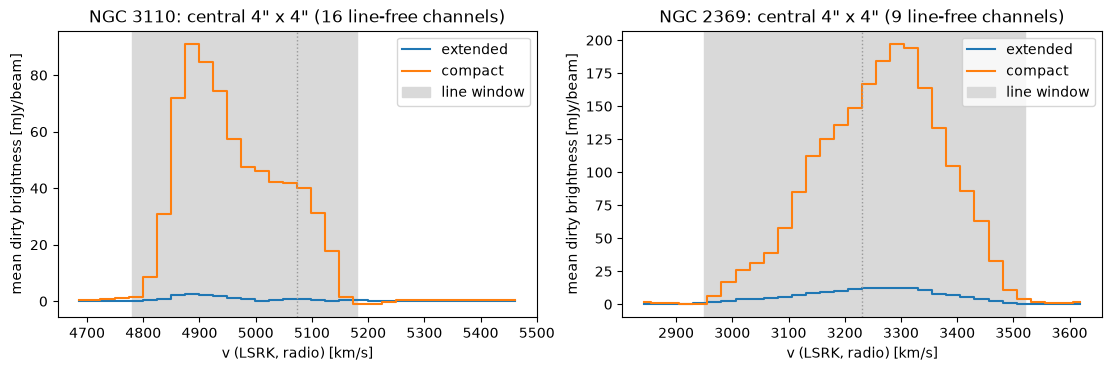

In [ ]:
# Line check: dirty-cube spectrum averaged over the central 4" x 4" -- the
# line should sit inside the 32 channels, with line-free channels at both ends.
c, h = IMSIZE // 2, int(2.0 / CELL_ARCSEC)
fig, axes = plt.subplots(1, len(GALAXIES), figsize=(11, 3.6), constrained_layout=True)
for ax, g in zip(axes, GALAXIES):
    for config in CONFIGS:
        spec = cubes[g["key"], config]["dirty"][:, c - h:c + h, c - h:c + h].mean(axis=(1, 2))
        ax.step(g["velocities"], spec * 1e3, where="mid", label=config)
    ax.axvline(g["vsys"], color="0.6", ls=":", lw=1)
    ax.axvspan(*g["line_kms"], color="0.85", zorder=0, label="line window")
    ax.set_xlabel("v (LSRK, radio) [km/s]")
    ax.set_ylabel("mean dirty brightness [mJy/beam]")
    ax.set_title(f"{g['label']}: central 4\" x 4\" ({len(g['noise_channels'])} line-free channels)")
    ax.legend()
plt.show()

### Scales the data can contain

An interferometer samples the sky's Fourier plane only between its shortest
and longest baselines, so each configuration constrains a limited range of
angular scales:

* **smallest**: the finest fringe, lambda / B_max (at the cube's highest
  frequency). Structure finer than this is not in the visibilities at all.
* **largest recoverable scale (LRS)**: ALMA's 0.983 lambda / L5, L5 the 5th
  percentile baseline (at the lowest frequency). Smooth emission broader than
  this is resolved out -- the data are blind to it.

Both from the UVW of every unflagged line-spw row. The deconvolution uses the
LRS (section 2): the model is not allowed structure the data cannot see.

In [7]:
C_KMS = 2.99792458e5


def baselines_m(msname, field, spw):
    '''(u, v) baseline lengths [m] of every unflagged row of `field` in `spw`.'''
    tb = table()
    tb.open(os.path.join(msname, "DATA_DESCRIPTION"))
    ddids = [d for d, s in enumerate(tb.getcol("SPECTRAL_WINDOW_ID")) if s == spw]
    tb.close()
    tb.open(msname)
    sub = tb.query(f"FIELD_ID=={field_id(msname, field)} && DATA_DESC_ID IN {ddids} && !FLAG_ROW",
                   columns="UVW")
    uvw = sub.getcol("UVW")
    sub.close()
    tb.close()
    return np.hypot(uvw[0], uvw[1])


scale_limits = {}
for g in GALAXIES:
    nu_hi = RESTFREQ_GHZ * 1e9 * (1 - g["velocities"].min() / C_KMS)      # radio convention
    nu_lo = RESTFREQ_GHZ * 1e9 * (1 - g["velocities"].max() / C_KMS)
    for config in CONFIGS:
        b = np.concatenate([baselines_m(p, g["field"], line_setup(p, g["field"])[0])
                            for p in g["configs"][config]])
        smallest = np.degrees(2.99792458e8 / nu_hi / b.max()) * 3600.0
        lrs = np.degrees(0.983 * 2.99792458e8 / nu_lo / np.percentile(b, 5)) * 3600.0
        scale_limits[g["key"], config] = dict(smallest=smallest, lrs=lrs, b_max=b.max(), l5=np.percentile(b, 5))
        print(f"{g['label']:<9} {config:<9} baselines {b.min():6.1f}-{b.max():7.1f} m (L5 {np.percentile(b, 5):6.1f} m): "
              f'smallest scale {smallest:.3f}" = {smallest / CELL_ARCSEC:3.0f} px, '
              f'LRS {lrs:5.2f}" = {lrs / CELL_ARCSEC:3.0f} px')

NGC 3110  extended  baselines   14.4- 2403.1 m (L5  109.6 m): smallest scale 0.113" =   6 px, LRS  2.45" = 123 px
NGC 3110  compact   baselines   12.6-  451.3 m (L5   27.5 m): smallest scale 0.604" =  30 px, LRS  9.78" = 489 px
NGC 2369  extended  baselines   14.0- 2293.9 m (L5   89.1 m): smallest scale 0.118" =   6 px, LRS  3.00" = 150 px
NGC 2369  compact   baselines   12.2-  388.9 m (L5   26.6 m): smallest scale 0.696" =  35 px, LRS 10.04" = 502 px


## 2. 2D-1D deconvolution

`simple/deconvolve.deconvolve` on each configuration's dirty cube + PSF cube,
all four in parallel, with the module's default settings: the deepest
decomposition the cube allows (8 starlet scales x 5 CDF 9/7 levels for
800 x 800 x 32), 60 FISTA iterations, reweighted L1 after 20 iterations,
positivity, and thresholds of 4 x (image-domain noise) x (each sub-band's
white-noise response) -- one uniform lambda on the normalized dictionary.
Thresholds taken from each sub-band's own MAD of the dirty cube (this
solver's earlier rule) are ~0 in sub-bands the PSF does not sample and
source-inflated where it does; on a ground-truth simulation with the real
compact PSF that rule produced exactly the arc/knot artifacts of the first
version of this notebook, and the uniform rule removed them (see
`simple/deconvolve.py`).

Two optional settings, off by default: **lrs_cut** zeroes every starlet
plane beyond the largest recoverable scale (section 1), and
**noise_from_line_free** raises each spatial scale's thresholds to the real
correlated noise measured on the line-free channels (10-60x white at 0.3-5"
in the extended data). Without them the extended models carry a diffuse
plateau at scales the extended data cannot see (beyond their ~2.5-3" LRS;
its flux keeps rising with iterations); with both on for extended that
plateau is gone, but the arms fragment and the fit to the data drops
(N(model)/dirty peak 0.57-0.72). `N(model)/dirty peak` is the fit check from
`deconvolve.py`'s docstring: the model re-convolved with the PSF, against the
dirty cube, both in Jy/beam -- it should approach 1.

In [8]:
# 2D-1D deconvolution settings, one set per configuration: keyword arguments of
# simple/deconvolve.deconvolve (plus lrs_cut / noise_from_line_free, see below).
DECONV = dict(
    extended=dict(
        n_iter=60,            # FISTA iterations
        k_sigma=5.0,          # threshold = k_sigma x image-domain noise x sub-band white-noise response
        num_scales_2d=None,   # spatial starlet scales;  None = deepest the grid allows
        num_levels_1d=None,   # spectral CDF 9/7 levels; None = deepest the channels allow
        reweight=True,        # reweighted L1 after burn_in_iters? False = plain soft-thresholding throughout
        burn_in_iters=20,     # plain soft-thresholding iterations before reweighted L1
        reweight_eps=1e-2,    # reweighted threshold: T / (|previous coeff| / T + eps)
        positivity=True,      # clip the model to >= 0 every iteration
        lrs_cut=False,        # zero every starlet plane beyond this configuration's largest recoverable scale
        noise_from_line_free=False,  # thresholds x (real / white noise) per spatial scale, from line-free channels
        # (lrs_cut + noise_from_line_free both True remove the extended diffuse plateau,
        #  but also fragment the arms and under-fit: N(model)/dirty peak 0.57-0.72)
    ),
    compact=dict(
        n_iter=60,
        k_sigma=5.0,
        num_scales_2d=None,
        num_levels_1d=None,
        reweight=True,
        burn_in_iters=20,
        reweight_eps=1e-2,
        positivity=True,
        lrs_cut=False,               # compact's LRS (~10") is beyond the deepest plane: this drops nothing
        noise_from_line_free=False,  # (True adds a halo to compact: +18% flux)
    ),
)


def solver_kwargs(g, config):
    '''DECONV[config] as keyword arguments of deconvolve() for galaxy `g`.'''
    d = DECONV[config]
    kw = {k: v for k, v in d.items() if k not in ("noise_from_line_free", "lrs_cut")}
    kw["noise_channels"] = g["noise_channels"] if d["noise_from_line_free"] else None
    kw["max_scale_px"] = scale_limits[g["key"], config]["lrs"] / CELL_ARCSEC if d["lrs_cut"] else None
    return kw


VERBOSE = True            # stream each run's setup + progress into the cell below
PRINT_EVERY = 1           # ... every PRINT_EVERY iterations

# Threads per deconvolution worker for the wavelet transforms (up to 4 workers
# run at once, so up to 4 x this many cores); results do not depend on it.
os.environ["SIMPLE_NUM_THREADS"] = "8"

for config in CONFIGS:
    d = DECONV[config]
    print(f"{config:<9}", ", ".join(f"{k}={v}" for k, v in d.items()))
    print(f"{'':<9} -> {d['num_scales_2d'] or max_scales_2d(IMSIZE, IMSIZE)} starlet scales x "
          f"{d['num_levels_1d'] or max_levels_1d(NCHAN)} CDF 9/7 levels")
print(f"verbose={VERBOSE} every {PRINT_EVERY} iteration(s); "
      f"{os.environ['SIMPLE_NUM_THREADS']} threads per worker")

# --- the same deconvolution on ONE compact cube, run right here -------------
# Set RUN_COMPACT_TEST = True and run this cell to try the settings above on
# one compact cube (~10-15 min). In this process, so every iteration prints
# below. The result is kept in `compact_test` (model + history), not written
# to disk: the next cell deconvolves all four cubes and writes their FITS.
RUN_COMPACT_TEST = False
COMPACT_TEST_GALAXY = "ngc3110"          # or "ngc2369"
if RUN_COMPACT_TEST:
    r = cubes[COMPACT_TEST_GALAXY, "compact"]
    g = next(g for g in GALAXIES if g["key"] == COMPACT_TEST_GALAXY)
    model, history = deconvolve(r["psf"], r["dirty"], verbose=VERBOSE, print_every=PRINT_EVERY,
                                label=f"[{COMPACT_TEST_GALAXY} compact] ", **solver_kwargs(g, "compact"))
    compact_test = dict(model=model, history=history)

extended  n_iter=60, k_sigma=5.0, num_scales_2d=None, num_levels_1d=None, reweight=True, burn_in_iters=20, reweight_eps=0.01, positivity=True, lrs_cut=False, noise_from_line_free=False
          -> 8 starlet scales x 5 CDF 9/7 levels
compact   n_iter=60, k_sigma=5.0, num_scales_2d=None, num_levels_1d=None, reweight=True, burn_in_iters=20, reweight_eps=0.01, positivity=True, lrs_cut=False, noise_from_line_free=False
          -> 8 starlet scales x 5 CDF 9/7 levels
verbose=True every 1 iteration(s); 8 threads per worker


In [9]:
def model_paths(g, config):
    d = out_dir(g, config)
    return (os.path.join(d, "model_cube.fits"), os.path.join(d, "deconvolution_history.json"),
            os.path.join(d, "deconvolution_params.json"))


def made_with_current_params(params_path, config):
    if not os.path.exists(params_path):
        return False
    with open(params_path) as f:
        return json.load(f) == dict(DECONV[config], psf_factor=PSF_FACTOR)

todo = []
for g in GALAXIES:
    for config in CONFIGS:
        fits_path, hist_path, params_path = model_paths(g, config)
        if (REUSE and os.path.exists(fits_path) and os.path.exists(hist_path)
                and made_with_current_params(params_path, config)):
            cubes[g["key"], config]["model"] = read_cube(fits_path)
            with open(hist_path) as f:
                cubes[g["key"], config]["history"] = json.load(f)
            print(f"[{g['label']} {config}] REUSE=1: loaded {os.path.relpath(fits_path, REPO_ROOT)}")
        else:
            todo.append((g, config))

if todo:
    print(f"deconvolving {len(todo)} cube(s) in parallel ...", flush=True)
    ctx = multiprocessing.get_context("spawn")
    with ctx.Manager() as manager, ctx.Pool(len(todo)) as pool:
        log = manager.Queue()                 # worker progress lines -> printed here, live
        runs = [pool.apply_async(deconvolve, (cubes[g["key"], cfg]["psf"], cubes[g["key"], cfg]["dirty"]),
                                 dict(solver_kwargs(g, cfg), verbose=VERBOSE, print_every=PRINT_EVERY,
                                      log=log.put, label=f"[{g['label']} {cfg}] "))
                for g, cfg in todo]
        while not all(r.ready() for r in runs) or not log.empty():
            try:
                print(log.get(timeout=1), flush=True)
            except queue.Empty:
                pass
        outs = [r.get() for r in runs]
    for (g, config), (model, history) in zip(todo, outs):
        r = cubes[g["key"], config]
        r["model"], r["history"] = model, history
        fits_path, hist_path, params_path = model_paths(g, config)
        write_cube_fits(model, r["template"], fits_path, "Jy/pixel")
        with open(params_path, "w") as f:
            json.dump(dict(DECONV[config], psf_factor=PSF_FACTOR), f, indent=1)
        with open(hist_path, "w") as f:
            json.dump(history, f, indent=1)
        print(f"[{g['label']} {config}] wrote {os.path.relpath(fits_path, REPO_ROOT)}")

for g in GALAXIES:
    for config in CONFIGS:
        last = cubes[g["key"], config]["history"][-1]
        print(f"{g['label']:<9} {config:<9} iter {last['iter']}: N(model)/dirty peak = "
              f"{last['peak_ratio']:.3f}, residual rms = {last['residual_rms'] * 1e3:.3f} mJy/beam, "
              f"model flux = {last['flux']:.2f} Jy (sum over channels), active voxels = {last['active']:,}")

deconvolving 4 cube(s) in parallel ...
[NGC 3110 extended] [setup] zero-spacing response |sum(PSF)| = 318.35 (MEASURED -> keep coarsest band)
[NGC 3110 compact] [setup] zero-spacing response |sum(PSF)| = 1896.00 (MEASURED -> keep coarsest band)
[NGC 3110 extended] [setup] 8 starlet scales x 5 CDF 9/7 levels; step 1/L = 3.332e-04; image noise (step units) = 2.359e-07; thresholds 5.0 sigma: 6.06e-10 .. 1.48e-06; 60 iterations, reweighting from iteration 20, positivity=True
[NGC 2369 extended] [setup] zero-spacing response |sum(PSF)| = 469.91 (MEASURED -> keep coarsest band)
[NGC 2369 compact] [setup] zero-spacing response |sum(PSF)| = 757.05 (MEASURED -> keep coarsest band)
[NGC 3110 compact] [setup] 8 starlet scales x 5 CDF 9/7 levels; step 1/L = 1.149e-04; image noise (step units) = 2.276e-07; thresholds 5.0 sigma: 5.84e-10 .. 1.43e-06; 60 iterations, reweighting from iteration 20, positivity=True
[NGC 3110 extended] iter   0  residual_rms=1.9747e-03  flux=    3.39 Jy  active=9984872  

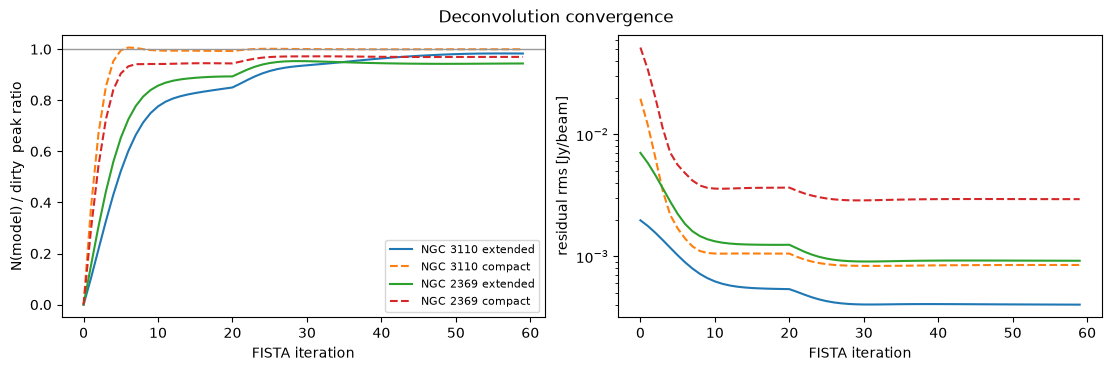

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
for g in GALAXIES:
    for config, ls in zip(CONFIGS, ("-", "--")):
        hist = cubes[g["key"], config]["history"]
        it = [h["iter"] for h in hist]
        axes[0].plot(it, [h["peak_ratio"] for h in hist], ls, label=f"{g['label']} {config}")
        axes[1].semilogy(it, [h["residual_rms"] for h in hist], ls, label=f"{g['label']} {config}")
axes[0].axhline(1, color="0.6", lw=1)
axes[0].set_ylabel("N(model) / dirty  peak ratio")
axes[1].set_ylabel("residual rms [Jy/beam]")
for ax in axes:
    ax.set_xlabel("FISTA iteration")
axes[0].legend(fontsize=8)
fig.suptitle("Deconvolution convergence")
plt.show()

## 3. Restoration with a clean beam

Model (Jy/pixel) convolved with a peak-1 Gaussian clean beam -> Jy/beam of
that beam. Each extended model gets its own beam; each compact model gets
both its own beam and the same galaxy's extended beam. First a check that
each fitted Gaussian actually matches its PSF's main lobe (central channel).

In [14]:
for g in GALAXIES:
    for config in CONFIGS:
        r = cubes[g["key"], config]
        psf_mid = r["psf"][NCHAN // 2]
        kernel = gaussian_beam(psf_mid.shape, CELL_ARCSEC, *r["beam"])
        lobe = kernel > 0.5                      # inside the fitted half-power contour
        print(f"{g['label']:<9} {config:<9} max |PSF - clean beam| inside its FWHM: "
              f"{np.abs(psf_mid - kernel)[lobe].max():.3f}")

for g in GALAXIES:
    ext_beam = cubes[g["key"], "extended"]["beam"]
    for config in CONFIGS:
        r = cubes[g["key"], config]
        r["restored"] = {"own": convolve_with_beam(r["model"], CELL_ARCSEC, *r["beam"])}
        if config == "compact":
            r["restored"]["extended"] = convolve_with_beam(r["model"], CELL_ARCSEC, *ext_beam)
        for which, cube in r["restored"].items():
            beam = r["beam"] if which == "own" else ext_beam
            out = os.path.join(out_dir(g, config), f"restored_{which}_beam.fits")
            write_cube_fits(cube, r["template"], out, "Jy/beam", beam=beam)
            print(f"[{g['label']} {config}] wrote {os.path.relpath(out, REPO_ROOT)}  "
                  f"(beam {beam[0]:.3f}\" x {beam[1]:.3f}\" @ {beam[2]:.1f} deg, "
                  f"peak {cube.max() * 1e3:.1f} mJy/beam)")

NGC 3110  extended  max |PSF - clean beam| inside its FWHM: 0.031
NGC 3110  compact   max |PSF - clean beam| inside its FWHM: 0.041
NGC 2369  extended  max |PSF - clean beam| inside its FWHM: 0.061
NGC 2369  compact   max |PSF - clean beam| inside its FWHM: 0.024
[NGC 3110 extended] wrote data/ngc3110/extended/cube/restored_own_beam.fits  (beam 0.220" x 0.172" @ -74.7 deg, peak 30.0 mJy/beam)


[NGC 3110 compact] wrote data/ngc3110/compact/cube/restored_own_beam.fits  (beam 1.418" x 0.976" @ 83.5 deg, peak 327.0 mJy/beam)
[NGC 3110 compact] wrote data/ngc3110/compact/cube/restored_extended_beam.fits  (beam 0.220" x 0.172" @ -74.7 deg, peak 17.3 mJy/beam)
[NGC 2369 extended] wrote data/ngc2369/extended/cube/restored_own_beam.fits  (beam 0.284" x 0.236" @ -87.6 deg, peak 54.3 mJy/beam)
[NGC 2369 compact] wrote data/ngc2369/compact/cube/restored_own_beam.fits  (beam 1.169" x 1.091" @ 53.1 deg, peak 575.3 mJy/beam)
[NGC 2369 compact] wrote data/ngc2369/compact/cube/restored_extended_beam.fits  (beam 0.284" x 0.236" @ -87.6 deg, peak 54.2 mJy/beam)


## 4. Moment-0 maps

Integrated intensity, sum over all 32 channels x 25 km/s. Rows: extended,
compact. Columns: dirty cube, 2D-1D model, model restored with its own clean
beam, model restored with the extended clean beam (compact only -- for the
extended row that is the previous panel). Clean beams are drawn bottom-left.

[NGC 3110 extended] wrote data/ngc3110/extended/cube/restored_2x_extended_beam.fits  (beam 0.441" x 0.343" @ -74.7 deg, peak 85.5 mJy/beam)
[NGC 3110 compact] wrote data/ngc3110/compact/cube/restored_2x_extended_beam.fits  (beam 0.441" x 0.343" @ -74.7 deg, peak 60.3 mJy/beam)
[NGC 2369 extended] wrote data/ngc2369/extended/cube/restored_2x_extended_beam.fits  (beam 0.569" x 0.471" @ -87.6 deg, peak 174.0 mJy/beam)
[NGC 2369 compact] wrote data/ngc2369/compact/cube/restored_2x_extended_beam.fits  (beam 0.569" x 0.471" @ -87.6 deg, peak 185.3 mJy/beam)


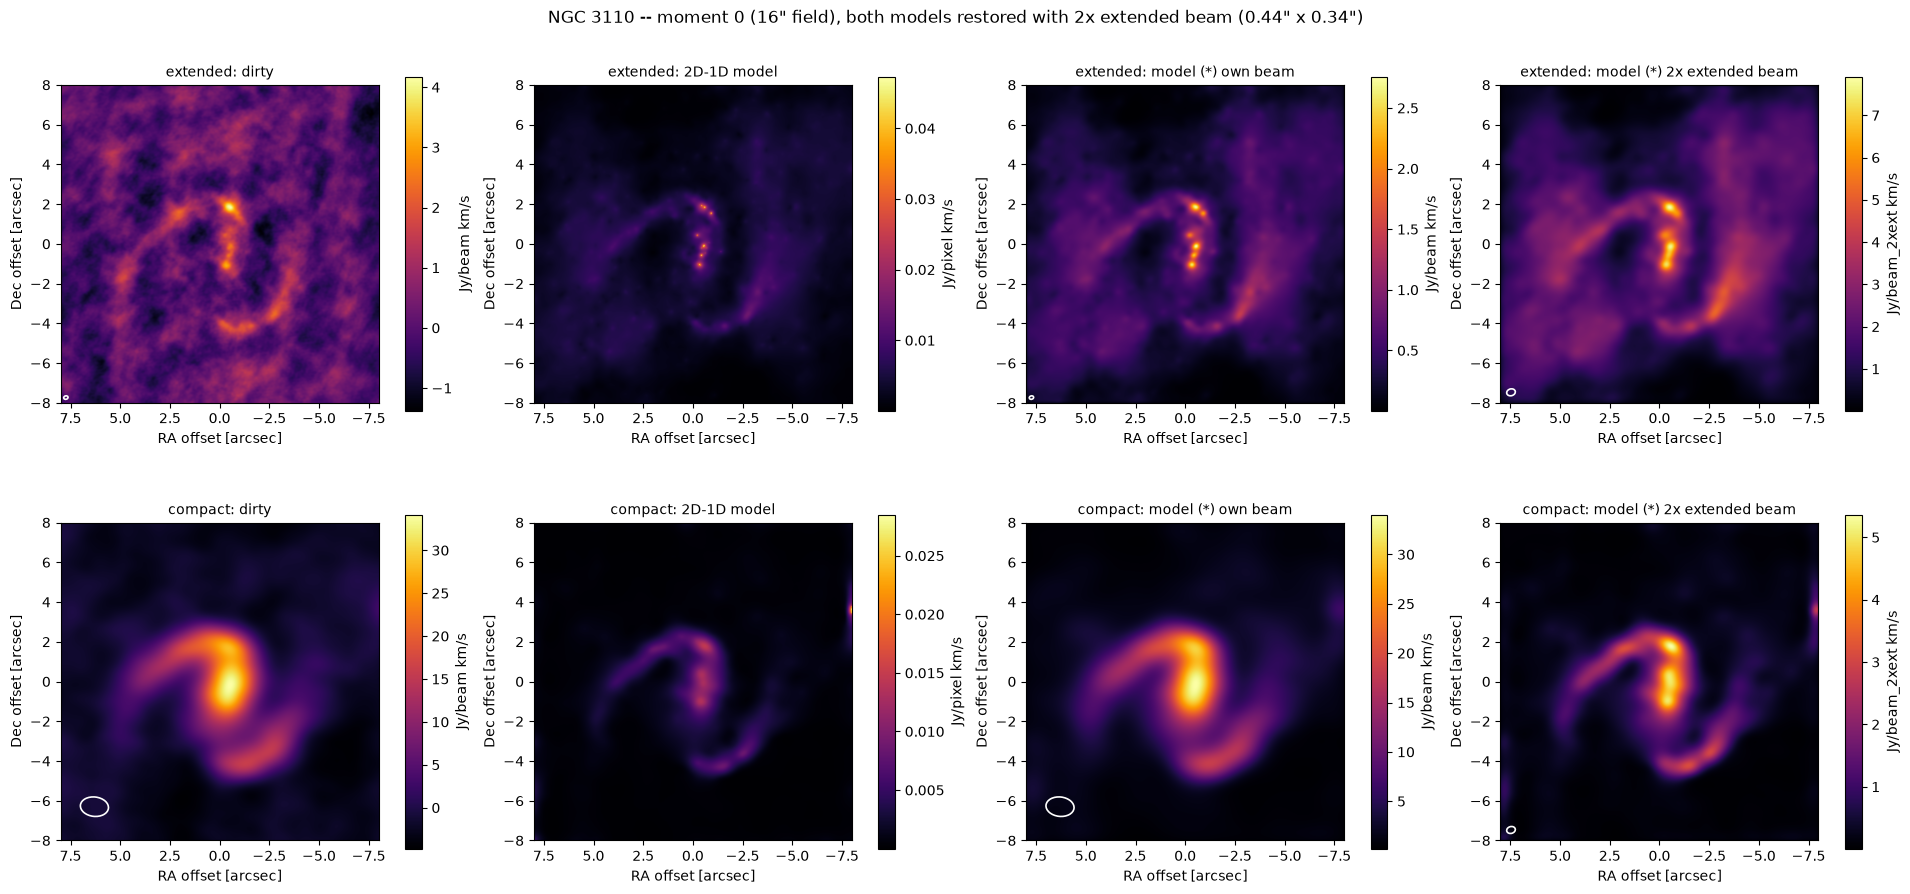

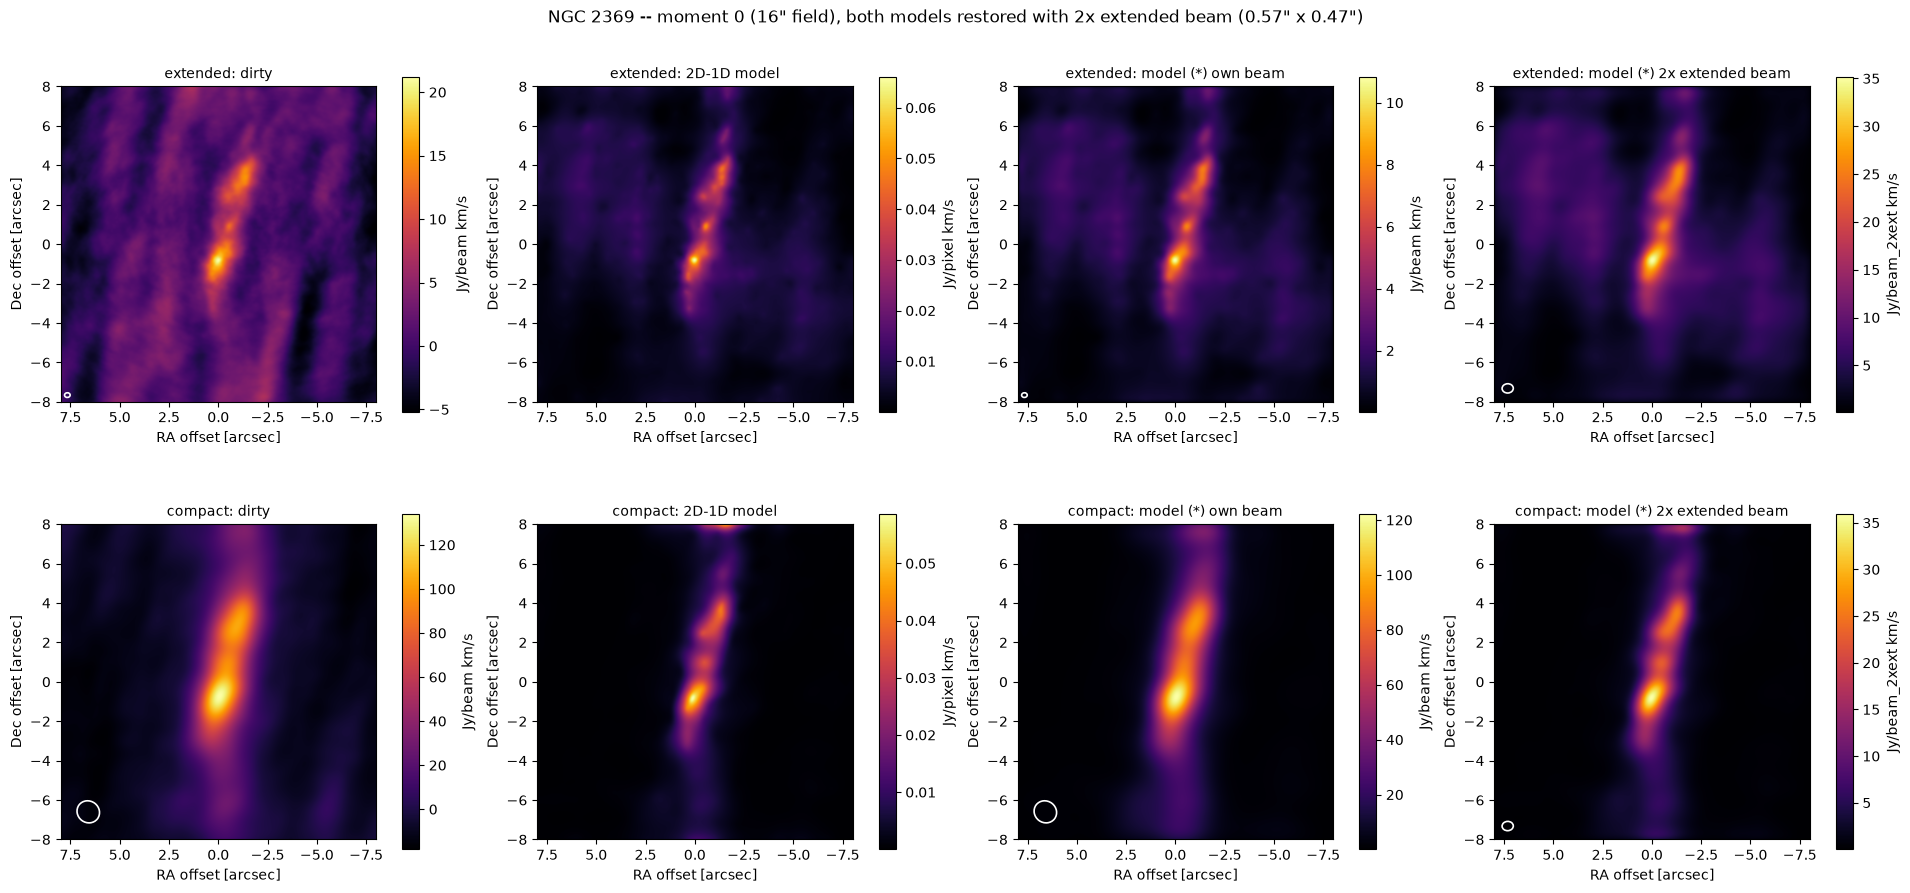

In [15]:
HALF = IMSIZE / 2 * CELL_ARCSEC
EXTENT = [HALF, -HALF, -HALF, HALF]


def moment0(cube):
    return cube.sum(axis=0) * WIDTH_KMS


def draw_beam(ax, beam, color="w"):
    '''Clean beam ellipse, bottom-left. PA is north through east; with RA
    offset (east) on +x, the major axis sits at 90 - PA from +x.'''
    bmaj, bmin, bpa = beam
    x0, y0 = HALF - 1.2 * bmaj, -HALF + 1.2 * bmaj
    ax.add_patch(Ellipse((x0, y0), width=bmaj, height=bmin, angle=90 - bpa,
                         facecolor="none", edgecolor=color, lw=1.2))


def show(ax, img, title, label, beam=None):
    '''One panel, colour scale spanning 100% of its own data (nanmin..nanmax).'''
    im = ax.imshow(img, origin="lower", extent=EXTENT, cmap="inferno",
                    vmin=np.nanmin(img), vmax=np.nanmax(img))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("RA offset [arcsec]")
    ax.set_ylabel("Dec offset [arcsec]")
    plt.colorbar(im, ax=ax, label=label, shrink=0.8)
    if beam is not None:
        draw_beam(ax, beam)

for g in GALAXIES:
    bmaj, bmin, bpa = cubes[g["key"], "extended"]["beam"]
    beam_2x = (2 * bmaj, 2 * bmin, bpa)
    for config in CONFIGS:          # both models at the same 2x-extended resolution
        r = cubes[g["key"], config]
        r["restored"]["2x_extended"] = convolve_with_beam(r["model"], CELL_ARCSEC, *beam_2x)
        out = os.path.join(out_dir(g, config), "restored_2x_extended_beam.fits")
        write_cube_fits(r["restored"]["2x_extended"], r["template"], out, "Jy/beam", beam=beam_2x)
        print(f"[{g['label']} {config}] wrote {os.path.relpath(out, REPO_ROOT)}  "
              f"(beam {beam_2x[0]:.3f}\" x {beam_2x[1]:.3f}\" @ {beam_2x[2]:.1f} deg, "
              f"peak {r['restored']['2x_extended'].max() * 1e3:.1f} mJy/beam)")

for g in GALAXIES:
    bmaj, bmin, bpa = cubes[g["key"], "extended"]["beam"]
    beam_2x = (2 * bmaj, 2 * bmin, bpa)
    fig, axes = plt.subplots(2, 4, figsize=(19, 9), constrained_layout=True)
    for row, config in enumerate(CONFIGS):
        r = cubes[g["key"], config]
        m_model = moment0(r["model"])
        show(axes[row, 0], moment0(r["dirty"]), f"{config}: dirty", "Jy/beam km/s", beam=r["beam"])
        show(axes[row, 1], m_model, f"{config}: 2D-1D model", "Jy/pixel km/s")
        show(axes[row, 2], moment0(r["restored"]["own"]), f"{config}: model (*) own beam",
             "Jy/beam km/s", beam=r["beam"])
        show(axes[row, 3], moment0(r["restored"]["2x_extended"]),
             f"{config}: model (*) 2x extended beam", "Jy/beam_2xext km/s", beam=beam_2x)
    fig.suptitle(f"{g['label']} -- moment 0 (16\" field), both models restored with 2x extended beam "
                 f"({beam_2x[0]:.2f}\" x {beam_2x[1]:.2f}\")")
    plt.show()

Same maps, but the last column restores BOTH models with a beam twice the
size of the extended clean beam (2 bmaj, 2 bmin, same PA), so compact and
extended compare at one resolution; written to `restored_2x_extended_beam.fits`.

[NGC 3110 extended] wrote data/ngc3110/extended/cube/restored_2x_extended_beam.fits  (beam 0.441" x 0.343" @ -74.7 deg, peak 87.2 mJy/beam)
[NGC 3110 compact] wrote data/ngc3110/compact/cube/restored_2x_extended_beam.fits  (beam 0.441" x 0.343" @ -74.7 deg, peak 60.6 mJy/beam)
[NGC 2369 extended] wrote data/ngc2369/extended/cube/restored_2x_extended_beam.fits  (beam 0.569" x 0.471" @ -87.6 deg, peak 174.1 mJy/beam)
[NGC 2369 compact] wrote data/ngc2369/compact/cube/restored_2x_extended_beam.fits  (beam 0.569" x 0.471" @ -87.6 deg, peak 188.7 mJy/beam)


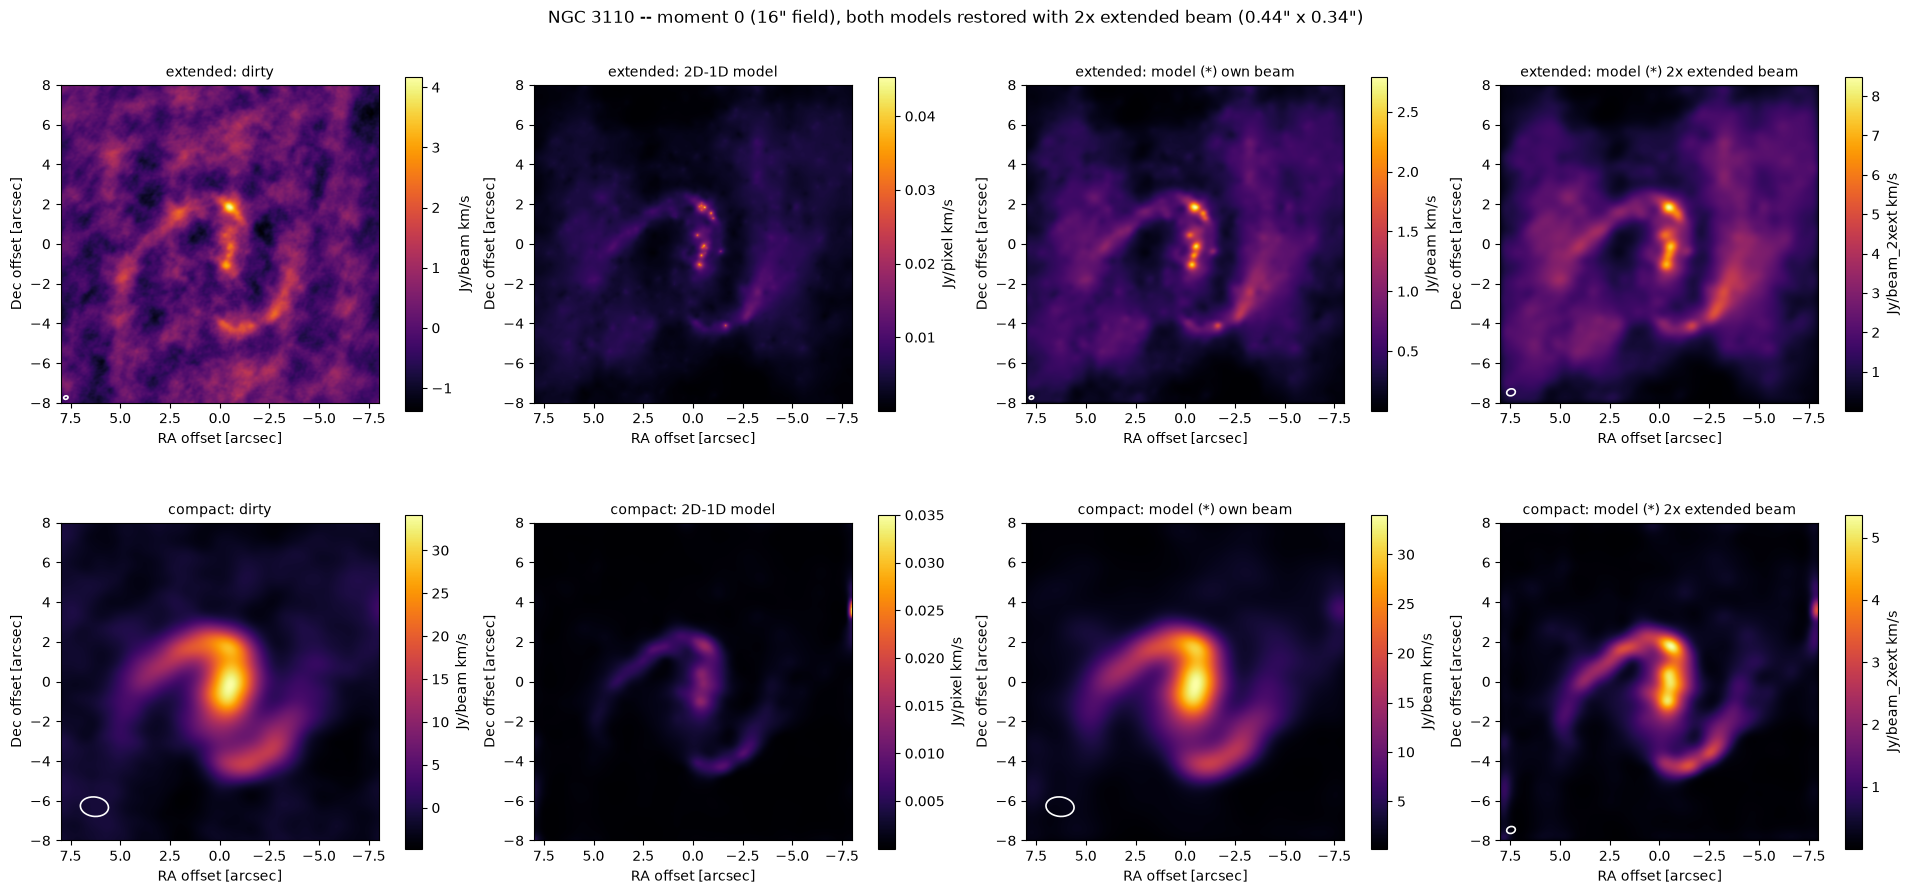

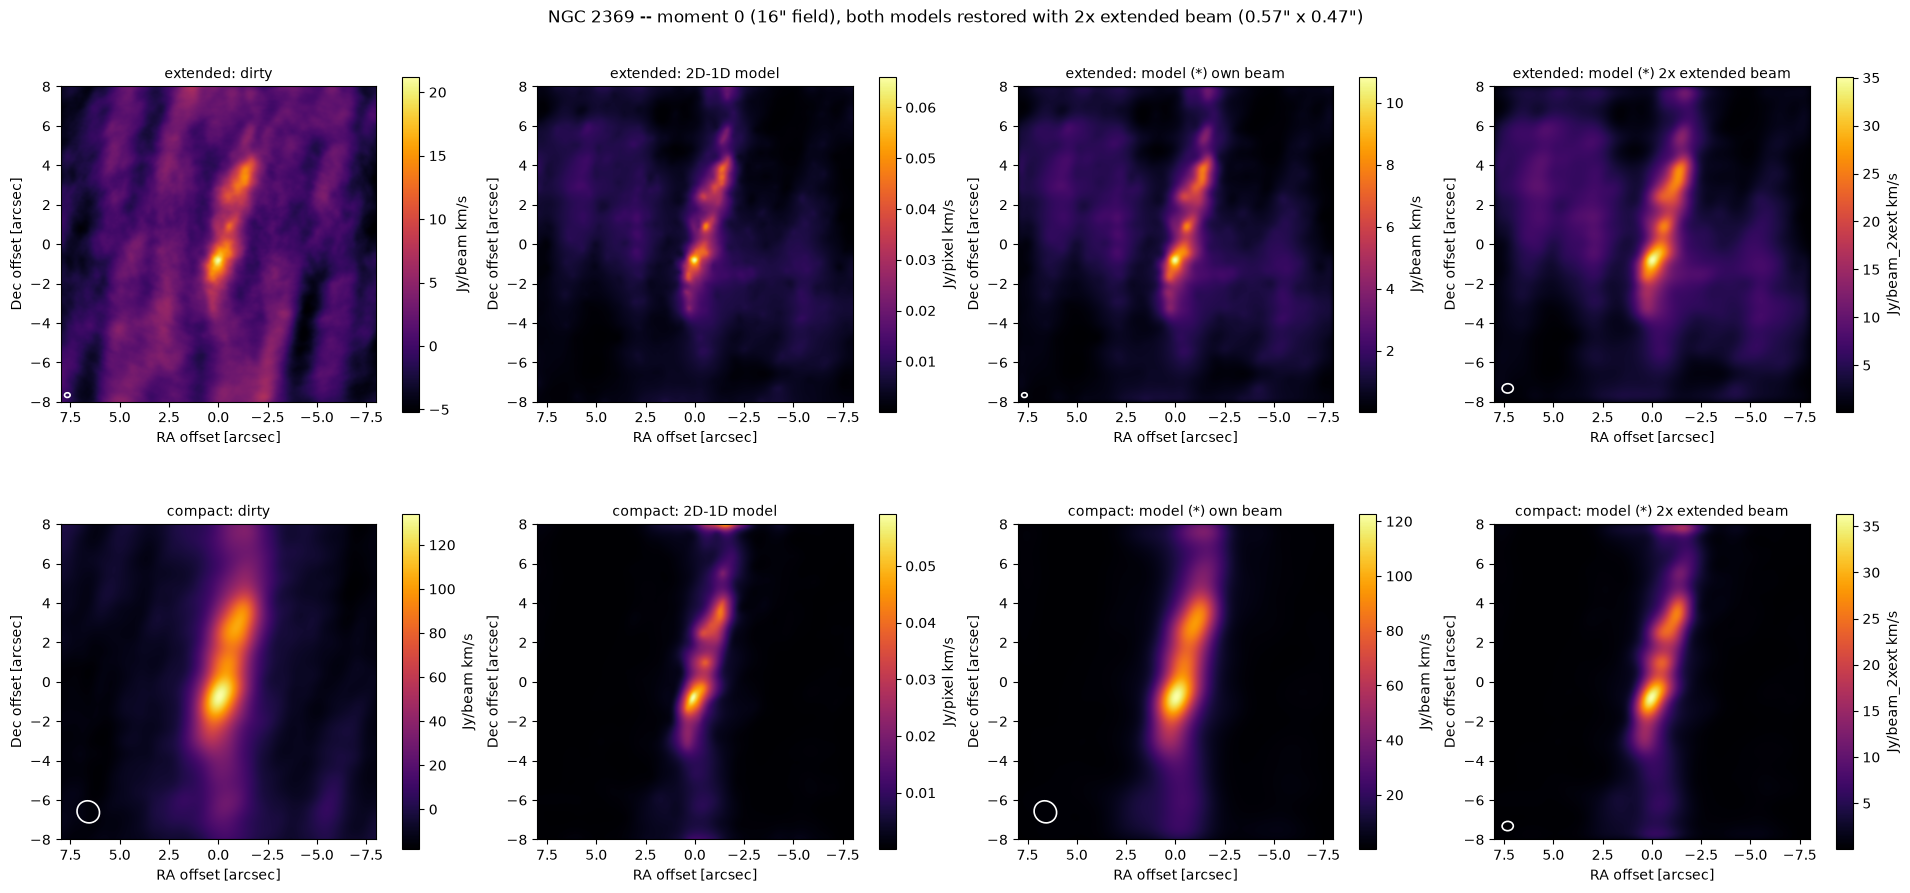

In [19]:
for g in GALAXIES:
    bmaj, bmin, bpa = cubes[g["key"], "extended"]["beam"]
    beam_2x = (2 * bmaj, 2 * bmin, bpa)
    for config in CONFIGS:          # both models at the same 2x-extended resolution
        r = cubes[g["key"], config]
        r["restored"]["2x_extended"] = convolve_with_beam(r["model"], CELL_ARCSEC, *beam_2x)
        out = os.path.join(out_dir(g, config), "restored_2x_extended_beam.fits")
        write_cube_fits(r["restored"]["2x_extended"], r["template"], out, "Jy/beam", beam=beam_2x)
        print(f"[{g['label']} {config}] wrote {os.path.relpath(out, REPO_ROOT)}  "
              f"(beam {beam_2x[0]:.3f}\" x {beam_2x[1]:.3f}\" @ {beam_2x[2]:.1f} deg, "
              f"peak {r['restored']['2x_extended'].max() * 1e3:.1f} mJy/beam)")

for g in GALAXIES:
    bmaj, bmin, bpa = cubes[g["key"], "extended"]["beam"]
    beam_2x = (2 * bmaj, 2 * bmin, bpa)
    fig, axes = plt.subplots(2, 4, figsize=(19, 9), constrained_layout=True)
    for row, config in enumerate(CONFIGS):
        r = cubes[g["key"], config]
        m_model = moment0(r["model"])
        show(axes[row, 0], moment0(r["dirty"]), f"{config}: dirty", "Jy/beam km/s", beam=r["beam"])
        show(axes[row, 1], m_model, f"{config}: 2D-1D model", "Jy/pixel km/s")
        show(axes[row, 2], moment0(r["restored"]["own"]), f"{config}: model (*) own beam",
             "Jy/beam km/s", beam=r["beam"])
        show(axes[row, 3], moment0(r["restored"]["2x_extended"]),
             f"{config}: model (*) 2x extended beam", "Jy/beam_2xext km/s", beam=beam_2x)
    fig.suptitle(f"{g['label']} -- moment 0 (16\" field), both models restored with 2x extended beam "
                 f"({beam_2x[0]:.2f}\" x {beam_2x[1]:.2f}\")")
    plt.show()

## 5. Compact vs extended at 2x the extended beam

Both models restored with a beam twice the extended clean beam (2 bmaj,
2 bmin, same PA -- the cubes of the previous cell). This is somewhat finer
than the compact data's own smallest scale (lambda / B_max ~ 0.6-0.7",
section 1), so the compact panel leans partly on its model's sparsity prior.
Each moment-0 map is normalized to [0, 1] (its own nanmin -> 0, nanmax -> 1)
before differencing, so the residual compares morphology free of the two
maps' different flux scales -- the extended data resolve out everything
beyond their ~2.5-3" largest recoverable scale. The first panel is the
compact model at its own clean-beam resolution, for reference.

[NGC 3110] normalized residual (compact - extended): rms 0.145, mean |resid| 0.122, range -0.327 .. +0.428
[NGC 2369] normalized residual (compact - extended): rms 0.101, mean |resid| 0.080, range -0.265 .. +0.200


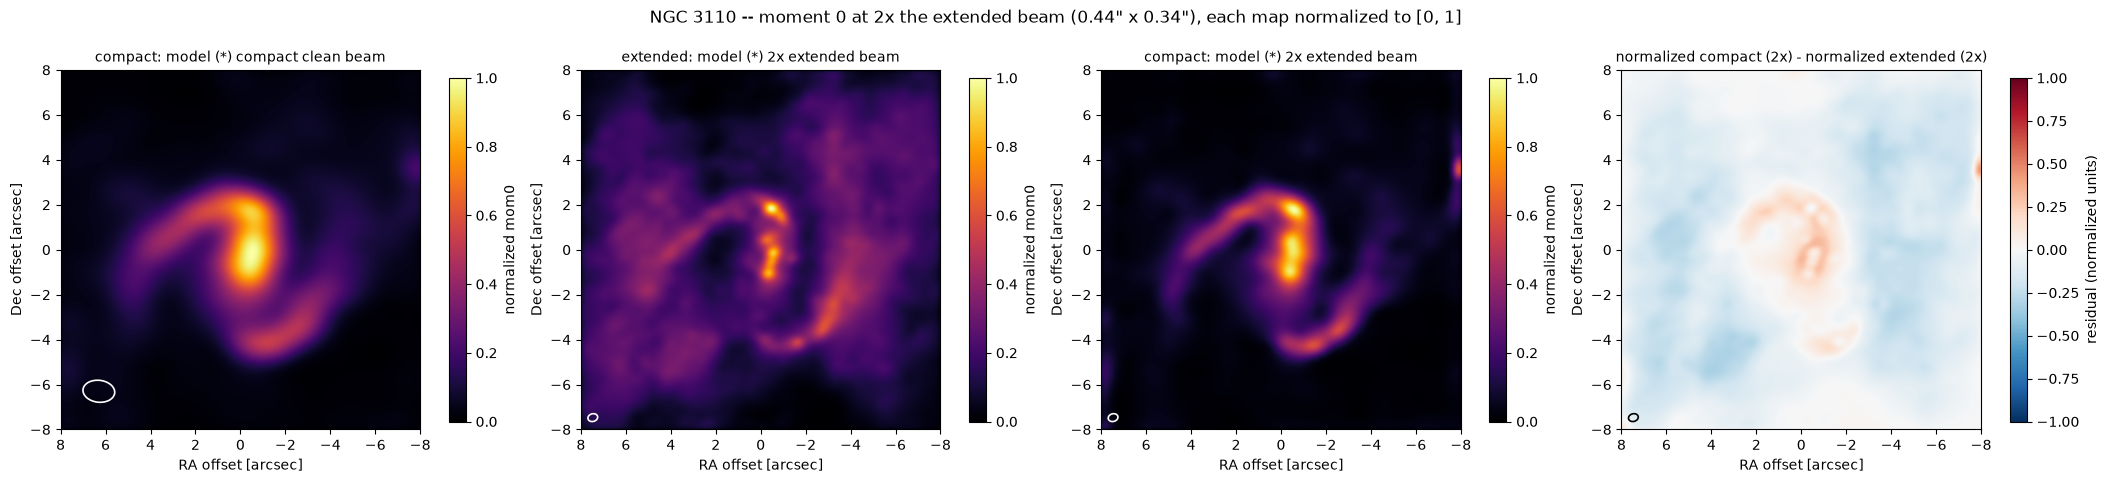

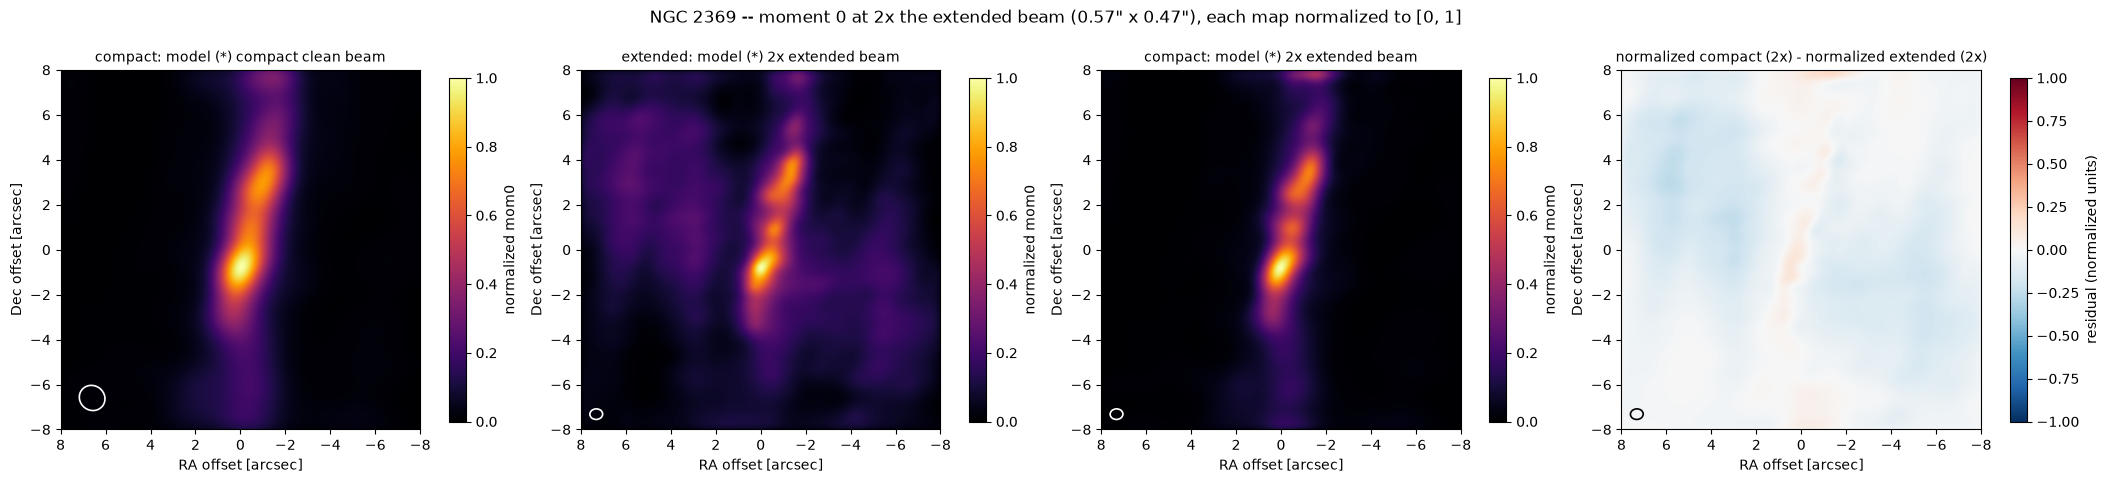

In [21]:
def normalized(img):
    '''Map `img` linearly onto [0, 1]: nanmin -> 0, nanmax -> 1.'''
    lo, hi = np.nanmin(img), np.nanmax(img)
    return (img - lo) / (hi - lo)


for g in GALAXIES:
    bmaj, bmin, bpa = cubes[g["key"], "extended"]["beam"]
    beam_2x = (2 * bmaj, 2 * bmin, bpa)
    # the 2x-extended-beam cubes of the previous cell
    norm_mom0 = {config: normalized(moment0(cubes[g["key"], config]["restored"]["2x_extended"]))
                 for config in CONFIGS}

    resid = norm_mom0["compact"] - norm_mom0["extended"]
    print(f"[{g['label']}] normalized residual (compact - extended): rms {np.sqrt(np.nanmean(resid ** 2)):.3f}, "
          f"mean |resid| {np.nanmean(np.abs(resid)):.3f}, range {np.nanmin(resid):+.3f} .. {np.nanmax(resid):+.3f}")

    compact_beam = cubes[g["key"], "compact"]["beam"]
    compact_own = normalized(moment0(cubes[g["key"], "compact"]["restored"]["own"]))

    fig, axes = plt.subplots(1, 4, figsize=(21, 4.8), constrained_layout=True)
    show(axes[0], compact_own, "compact: model (*) compact clean beam", "normalized mom0", beam=compact_beam)
    show(axes[1], norm_mom0["extended"], "extended: model (*) 2x extended beam", "normalized mom0", beam=beam_2x)
    show(axes[2], norm_mom0["compact"], "compact: model (*) 2x extended beam", "normalized mom0", beam=beam_2x)
    # residual on the maps' own scale: -vmax .. +vmax of the two normalized panels (-1 .. 1)
    vmax = max(np.nanmax(norm_mom0["compact"]), np.nanmax(norm_mom0["extended"]))
    im = axes[3].imshow(resid, origin="lower", extent=EXTENT, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    axes[3].set_title("normalized compact (2x) - normalized extended (2x)", fontsize=10)
    axes[3].set_xlabel("RA offset [arcsec]")
    axes[3].set_ylabel("Dec offset [arcsec]")
    plt.colorbar(im, ax=axes[3], label="residual (normalized units)", shrink=0.8)
    draw_beam(axes[3], beam_2x, color="k")
    fig.suptitle(f"{g['label']} -- moment 0 at 2x the extended beam "
                 f"({beam_2x[0]:.2f}\" x {beam_2x[1]:.2f}\"), each map normalized to [0, 1]")
    plt.show()

## FITS outputs

Per galaxy (`ngc3110`, `ngc2369`) and configuration (`extended`, `compact`),
in `data/<galaxy>/<config>/cube/`, all 800 x 800 x 32 on the galaxy's common
grid:

```
dirty_cube.fits                 dirty cube, Jy/beam
dirty_beam_cube.fits            PSF cube, peak 1 per channel, 1600 x 1600 (2x the field)
model_cube.fits                 2D-1D model, Jy/pixel
deconvolution_history.json      per-iteration diagnostics
deconvolution_params.json       the DECONV settings (+ PSF size) the model was made with
restored_own_beam.fits          model (*) own clean beam, Jy/beam
restored_extended_beam.fits     compact only: model (*) extended clean beam
restored_2x_extended_beam.fits  model (*) 2x extended clean beam (both configurations)
```